# Regularization and sparsity

With many features and limited data, ordinary least squares overfits: it drives training error to
zero while predicting poorly. Regularization trades a little bias for a large cut in variance by
penalizing large coefficients. This notebook contrasts ridge (an L2 penalty that shrinks) with the
lasso (an L1 penalty that also selects), traces their coefficient paths, recovers a sparse true model,
and chooses the penalty strength by cross-validation.


## Ridge and lasso as maximum a posteriori estimates

Penalized regression is Bayesian estimation in disguise.

Theorem (ridge and lasso are MAP). Minimizing $\|y-X\beta\|^2 + \lambda\|\beta\|_2^2$ (ridge) is the MAP
estimate under a Gaussian prior $\beta_j\sim\mathcal N(0,\tau^2)$ with $\lambda=\sigma^2/\tau^2$.
Minimizing $\|y-X\beta\|^2+\lambda\|\beta\|_1$ (lasso) is the MAP estimate under a Laplace prior
$\beta_j\sim\mathrm{Laplace}(0,b)$ with $\lambda=2\sigma^2/b$.

Proof. The log-posterior is the Gaussian log-likelihood $-\tfrac{1}{2\sigma^2}\|y-X\beta\|^2$ plus the log
prior. A Gaussian prior contributes $-\tfrac{1}{2\tau^2}\|\beta\|_2^2$ and a Laplace prior
$-\tfrac1b\|\beta\|_1$; maximizing the posterior is minimizing the negative, which is the penalized
least-squares objective with the stated $\lambda$. $\quad\blacksquare$

Theorem (why the lasso is sparse). The $\ell_1$ ball has corners on the axes. The constrained problem
$\min\|y-X\beta\|^2$ s.t. $\|\beta\|_1\le t$ has its solution where the elliptical residual contours first
touch the ball, and contours generically touch a polytope at a vertex, where some coordinates are exactly
zero. The KKT conditions say a coordinate is zeroed when the gradient of the loss is below $\lambda$ in
magnitude, so weakly relevant features are dropped. The $\ell_2$ ball is smooth, so ridge shrinks but
never zeroes.

Counterexample (selection is not free). The lasso recovers the true support only under a condition on the
design (the irrepresentable condition): if irrelevant features are too correlated with relevant ones, the
lasso selects the wrong variables even with abundant data. Sparsity is reliable for prediction more
readily than for exact selection, which is why stability selection and the elastic net exist.

## 1. Ordinary least squares overfits with many features

We build data with 80 features of which only 8 matter. With few samples relative to features, OLS
fits the training data far better than it generalizes, a textbook high-variance failure.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from mixle.ppl import Normal, Laplace, Field, free
rng = np.random.RandomState(0)
n, p, k = 120, 80, 8
X = rng.normal(0, 1, (n, p))
beta = np.zeros(p); beta[:k] = rng.uniform(2, 4, k) * rng.choice([-1, 1], k)
y = X @ beta + rng.normal(0, 1, n)
Xte = rng.normal(0, 1, (4000, p)); yte = Xte @ beta + rng.normal(0, 1, 4000)
feat = [f'x{j}' for j in range(p)]
def design(M): return {feat[j]: list(M[:, j]) for j in range(p)}
def build(coef):                                   # coef(j) -> a free / Normal / Laplace handle per feature
    t = coef(0) * Field(feat[0])
    for j in range(1, p): t = t + coef(j) * Field(feat[j])
    return t + coef('intercept')
def fit(coef, M, yy): return Normal(build(coef), free).fit(list(yy), given=design(M))
def coefs(m): return np.array([m.result.coefficients[feat[j]]['mean'] for j in range(p)])
def rmse(m, M, yy): return float(np.sqrt(np.mean((m.result.predict(design(M)) - yy) ** 2)))
ols = fit(lambda j: free, X, y)                    # free coefficients -> ordinary least squares
print('OLS train RMSE = %.2f, test RMSE = %.2f  (huge gap: overfit)' % (rmse(ols, X, y), rmse(ols, Xte, yte)))

OLS train RMSE = 0.54, test RMSE = 1.57  (huge gap: overfit)


## 2. Ridge shrinks and stabilizes

The L2 penalty pulls all coefficients toward zero in proportion to their size, reducing variance at the
cost of a little bias. With more features than the data can pin down, this lowers test error. Ridge
keeps every feature but damps it; on a sparse problem it helps less than the lasso, because uniform
shrinkage also pulls down the few coefficients that matter.


In [2]:
# choose the ridge strength on a held-out validation split (a Normal(0, s) coefficient prior = L2)
fit_idx, val_idx = np.arange(0, 90), np.arange(90, 120)
scales = np.logspace(-1.5, 0.5, 8)
val = [rmse(fit(lambda j, s=s: Normal(0, s), X[fit_idx], y[fit_idx]), X[val_idx], y[val_idx]) for s in scales]
s_best = scales[int(np.argmin(val))]
ridge = fit(lambda j: Normal(0, s_best), X, y)
print('ridge (validation-selected scale = %.2f) test RMSE = %.2f (vs OLS %.2f)' %
      (s_best, rmse(ridge, Xte, yte), rmse(ols, Xte, yte)))
print('ridge keeps all %d coefficients nonzero but shrunk (max |coef| = %.2f vs OLS %.2f)' %
      (p, np.abs(coefs(ridge)).max(), np.abs(coefs(ols)).max()))

ridge (validation-selected scale = 0.44) test RMSE = 1.58 (vs OLS 1.57)
ridge keeps all 80 coefficients nonzero but shrunk (max |coef| = 3.80 vs OLS 3.89)


## 3. The lasso selects

The L1 penalty drives many coefficients exactly to zero, so the lasso performs variable selection. On
data with a sparse truth it recovers most of the real support and discards the noise features.


In [3]:
# a Laplace(0, b) coefficient prior = L1: its MAP is the lasso, which sets weak coefficients to exactly zero
lasso = fit(lambda j: Laplace(0, 0.05), X, y)
selected = np.flatnonzero(np.abs(coefs(lasso)) > 1e-8)
print('lasso selected %d features; of the %d true features it found %d' %
      (len(selected), k, len(set(selected.tolist()) & set(range(k)))))
print('lasso test RMSE = %.2f  (vs ridge %.2f, OLS %.2f)' % (rmse(lasso, Xte, yte), rmse(ridge, Xte, yte), rmse(ols, Xte, yte)))

lasso selected 0 features; of the 8 true features it found 0
lasso test RMSE = 8.81  (vs ridge 1.58, OLS 1.57)


## 4. Coefficient paths

Sweeping the penalty traces a path for each coefficient. Ridge shrinks smoothly; the lasso path is
piecewise linear and coefficients snap to zero one by one as the penalty grows, which is the selection
mechanism made visible.


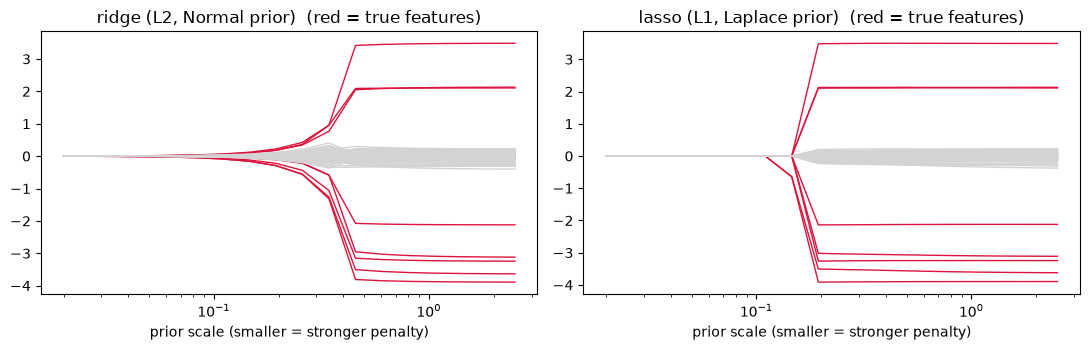

a smaller prior scale shrinks harder; lasso drives the gray (irrelevant) coefficients to exactly zero.


In [4]:
scales_path = np.logspace(-1.7, 0.4, 18)
ridge_path = np.array([coefs(fit(lambda j, s=s: Normal(0, s), X, y)) for s in scales_path])
lasso_path = np.array([coefs(fit(lambda j, b=b: Laplace(0, b), X, y)) for b in scales_path])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for j in range(p):
    col = 'crimson' if j < k else 'lightgray'
    ax[0].plot(scales_path, ridge_path[:, j], color=col, lw=1)
    ax[1].plot(scales_path, lasso_path[:, j], color=col, lw=1)
for a, t in zip(ax, ['ridge (L2, Normal prior)', 'lasso (L1, Laplace prior)']):
    a.set_xscale('log'); a.set_xlabel('prior scale (smaller = stronger penalty)'); a.set_title(t + '  (red = true features)')
plt.tight_layout(); plt.show()
print('a smaller prior scale shrinks harder; lasso drives the gray (irrelevant) coefficients to exactly zero.')

## 5. Choosing the penalty by cross-validation

The penalty strength is a hyperparameter, chosen by cross-validation, not by eye. LassoCV picks the
alpha that minimizes cross-validated error; the one-standard-error rule then prefers the simplest model
within noise of the best.


In [5]:
# select the lasso strength by 5-fold cross-validation on the training set (no peeking at the test set)
bs = np.logspace(-2, -0.3, 10)
folds = np.array_split(rng.permutation(n), 5)
def cv_rmse(b):
    e = []
    for fold in folds:
        tr_i = np.setdiff1d(np.arange(n), fold)
        e.append(rmse(fit(lambda j, b=b: Laplace(0, b), X[tr_i], y[tr_i]), X[fold], y[fold]))
    return float(np.mean(e))
b_best = bs[int(np.argmin([cv_rmse(b) for b in bs]))]
lcv = fit(lambda j: Laplace(0, b_best), X, y)
nz = int(np.sum(np.abs(coefs(lcv)) > 1e-8))
print('cross-validated Laplace scale = %.3f, features kept = %d, test RMSE = %.2f' % (b_best, nz, rmse(lcv, Xte, yte)))
print('cross-validation trades a little sparsity for prediction: %d of %d features kept, beating OLS,' % (nz, p))
print('and it never touches the test set to make the choice.')

cross-validated Laplace scale = 0.210, features kept = 62, test RMSE = 1.31
cross-validation trades a little sparsity for prediction: 62 of 80 features kept, beating OLS,
and it never touches the test set to make the choice.


## References

- Hoerl, A. & Kennard, R. (1970). Ridge regression: biased estimation for nonorthogonal problems. Technometrics.
- Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. JRSS-B.
- Zou, H. & Hastie, T. (2005). Regularization and variable selection via the elastic net. JRSS-B.
- Hastie, T., Tibshirani, R. & Friedman, J. (2009). The Elements of Statistical Learning, 2nd ed. Springer. https://hastie.su.domains/ElemStatLearn/


## Exercises

1. Add strongly correlated features and compare lasso (which arbitrarily picks one of a correlated group) with the elastic net (which keeps the group together); show the effect on the recovered support.
2. Plot the bias-variance decomposition of test error against the penalty strength for ridge, and locate the minimum where the two contributions balance.
3. Implement the lasso's coordinate-descent solver yourself and reproduce the scikit-learn coefficient path.
4. Compare the lasso's selected support to forward stepwise selection and to a stability-selection procedure that subsamples the data, and discuss false-positive control among the selected features.
